# Modelo: MLP Denso

Primer modelo neuronal del taller. Se trata de una red feedforward 
multicapa (Multi-Layer Perceptron) con capas totalmente conectadas.

## Arquitectura

Para cada combinación de ventanas:
1. Se aplana la entrada `X` de forma `(n, ventana, 23)` a `(n, ventana × 23)`.
2. Se pasa por una capa densa oculta con activación ReLU (64 neuronas).
3. Capa de salida con 23 neuronas (los 23 activos), sin activación.

Optimizador Adam, función de pérdida MAE, batch size 64, hasta 50 epochs 
con `EarlyStopping` sobre la pérdida de validación (paciencia 5).

## Por qué este diseño

- **Simple a propósito.** Empezamos con la arquitectura más básica que 
  añade no-linealidad sobre la regresión lineal. Si supera al baseline 
  lineal, sabemos que la no-linealidad aporta. Si no, hay que revisar 
  el entrenamiento antes de complicar la red.
- **Misma estructura del loop que en los baselines** (16 combinaciones, 
  mismo split, mismas métricas). Esto facilita la comparación directa.

## Imports y carga de datos

In [196]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import os
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
from tensorflow.keras.optimizers import Adam

warnings.simplefilter(action="ignore", category=FutureWarning)

# Reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Carga de datos
start_date = '1945-01-01'
tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD',
                   'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM',
                   'MO', 'MRK', 'MSI', 'PG', 'XOM']

precios_close = yf.download(tickers_validos, start=start_date,
                            auto_adjust=True, progress=False)['Close']
precios_close.dropna(axis=1, inplace=True)

returns = precios_close.pct_change().dropna()
print(f"Returns: {returns.shape}")

Returns: (16196, 23)


## Funciones auxiliares 

In [197]:
def create_time_series_data(data, input_window_size, output_window_size):
    X, y = [], []
    data_array = data.values if isinstance(data, pd.DataFrame) else data
    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        input_seq = data_array[i : i + input_window_size]
        output_seq = data_array[i + input_window_size : i + input_window_size + output_window_size]
        X.append(input_seq)
        y.append(np.mean(output_seq, axis=0))
    return np.array(X), np.array(y)


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def split_triple(X, y, test_size=0.1, val_size=0.05):
    """Triple split cronológico (sin shuffle)."""
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size, shuffle=False
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

## Decisiones de diseño

A continuación se documentan las decisiones tomadas y el razonamiento 
detrás de cada una.

### Preprocesado: StandardScaler ajustado solo en train

Se normaliza tanto la entrada `X` como la salida `y` con `StandardScaler`. 
Las redes neuronales aprenden mejor cuando los datos están en escala ~1: 
los pesos iniciales se sortean asumiendo esa escala, y los gradientes se 
mueven en magnitudes adecuadas. Los returns sin normalizar (escala ~0.01) 
producen gradientes minúsculos y aprendizaje lento.

**Crítico:** el scaler se ajusta SOLO con datos de train; val y test se 
transforman con esos parámetros ya fijados. Ajustarlo con todos los datos 
sería *data leakage*. Tras predecir, se des-normaliza con `inverse_transform` 
para reportar MAE en la escala original (returns), comparable con los 
baselines.

### Arquitectura: 2 capas ocultas (128 → 64) con ReLU y Dropout

La red consta de:
- Capa de aplanado: `Flatten` que convierte `(días, 23)` en un vector de 
  `días × 23` valores.
- Capa densa de **128 neuronas** con activación ReLU.
- **Dropout 0.2** entre capas ocultas.
- Capa densa de **64 neuronas** con activación ReLU.
- Dropout 0.2.
- Capa de salida lineal de 23 neuronas (sin activación, regresión).

Razones:
- **Dos capas ocultas en lugar de una.** Una sola capa densa con ReLU 
  añade poca expresividad sobre una regresión lineal. Con dos capas el 
  modelo puede componer transformaciones no lineales más complejas.
- **Tamaño decreciente (128 → 64):** patrón habitual en MLP de regresión, 
  conocido como "embudo". La primera capa amplía la representación, la 
  segunda la comprime hacia la salida.
- **Dropout 0.2:** regularización suave para combatir el overfitting. Con 
  ventanas de entrada grandes (input_window=90) la red tiene 274.839 
  parámetros frente a ~13.000 muestras de train; sin regularización 
  memoriza ruido.

### Optimizador: Adam con learning rate 0.0005

Adam es el optimizador estándar en deep learning desde 2015 porque adapta 
la tasa de aprendizaje por parámetro de forma automática.

Se usa `learning_rate=0.0005` (la mitad del valor por defecto, 0.001). 
Razón: con returns financieros, que son inherentemente ruidosos, un 
learning rate más bajo estabiliza el entrenamiento y reduce oscilaciones 
de val_loss epoch a epoch.

### Función de pérdida: MAE

Entrenar minimizando exactamente la métrica con la que se evalúa la 
competición. El enunciado especifica MAE como métrica oficial:

> "Los modelos se entrenarán para minimizar el error absoluto promedio (MAE)"

Si entrenásemos con MSE, el modelo optimizaría una función diferente a 
la que se le mide. La coherencia entre función de pérdida y métrica de 
evaluación es buena práctica.

### Batch size: 64

Tamaño estándar que ofrece un buen equilibrio entre estabilidad del 
gradiente (lotes muy pequeños son ruidosos) y velocidad de entrenamiento 
(lotes muy grandes hacen menos actualizaciones por epoch). Con ~13.000 
muestras de train, batches de 64 dan ~200 actualizaciones por epoch.

### Epochs: máximo 50, con EarlyStopping (paciencia 7)

Se permite hasta 50 epochs, pero el `EarlyStopping(patience=7)` para el 
entrenamiento si `val_loss` no mejora durante 7 epochs consecutivas:
- **No se fija un número arbitrario de epochs.** Algunas combinaciones 
  convergen en 8-10, otras necesitan más.
- **`restore_best_weights=True`** recupera los pesos del momento óptimo de 
  val_loss, no del último epoch. Aunque el modelo haya empezado a 
  sobreajustar tras la mejor epoch, el modelo final guardado es el que 
  mejor generalizaba.
- **Paciencia 7** es un balance: pequeña como para detectar deterioro, 
  pero suficiente para no parar prematuramente por una fluctuación 
  aleatoria.

### Triple split (train / validación / test) con shuffle aleatorio

El enunciado pide reportar resultados en train, validación y test:

> "Reportará el resultado en entrenamiento, en validación y en test para 
> cada combinación."

Se aplica un primer split 90/10 para test, y un segundo 5% del train para 
validación. La partición es aleatoria con semilla fija, siguiendo la 
indicación del enunciado:

> "La partición de entrenamiento test es aleatoria con la semilla marcada."

`RANDOM_SEED = 42` para reproducibilidad: cada ejecución produce los 
mismos splits.

### Visualización: callback que calcula MAE en escala real

Como el modelo entrena con datos normalizados, el `loss` interno de Keras 
está en escala normalizada y no es comparable con los baselines. Para 
solucionarlo se implementa `MAERealCallback`: tras cada epoch predice 
sobre train y val, des-normaliza con `inverse_transform`, y guarda el MAE 
en escala real.

Las gráficas incluyen:
- Curva train (azul) y val (naranja) en MAE real.
- Línea horizontal gris discontinua con el MAE de la regresión lineal en 
  test, como referencia visual de la cota a batir.

Esta visualización permite leer de un vistazo si el modelo está mejorando 
respecto al baseline lineal (val por debajo de la línea gris) o no.

**Trade-off asumido:** el callback hace dos predicciones extra por epoch, 
lo que ralentiza el entrenamiento. El coste se asume porque la 
interpretabilidad visual justifica el tiempo extra.

## Arquitectura del modelo

In [198]:
from tensorflow.keras.regularizers import l2

def construir_mlp(input_window, n_activos=23):
    modelo = Sequential([
        Input(shape=(input_window, n_activos)),
        Flatten(),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        Dense(n_activos)
    ])
    modelo.compile(optimizer=Adam(learning_rate=0.0005),
                   loss='mae', metrics=['mae'])
    return modelo

## Callback

In [199]:
from tensorflow.keras.callbacks import Callback
from sklearn.preprocessing import StandardScaler

class MAERealCallback(Callback):
    """
    Calcula MAE en escala original tras des-normalizar con scaler_y.
    Necesario porque el modelo entrena con datos normalizados y el loss
    interno de Keras está en escala normalizada.
    """
    def __init__(self, X_train_n, y_train_real, X_val_n, y_val_real, scaler_y):
        super().__init__()
        self.X_train_n = X_train_n
        self.y_train_real = y_train_real
        self.X_val_n = X_val_n
        self.y_val_real = y_val_real
        self.scaler_y = scaler_y
        self.mae_train = []
        self.mae_val = []

    def on_epoch_end(self, epoch, logs=None):
        pred_train = self.scaler_y.inverse_transform(
            self.model.predict(self.X_train_n, verbose=0))
        pred_val = self.scaler_y.inverse_transform(
            self.model.predict(self.X_val_n, verbose=0))

        self.mae_train.append(np.mean(np.abs(self.y_train_real - pred_train)))
        self.mae_val.append(np.mean(np.abs(self.y_val_real - pred_val)))

## Loop sobre las 16 combinaciones

In [200]:
input_windows = [5, 10, 30, 90]
output_windows = [1, 5, 30, 90]

resultados = []
historiales = {}

os.makedirs('../models', exist_ok=True)

for in_w in input_windows:
    for out_w in output_windows:
        print(f"\n--- Entrenando MLP in={in_w}, out={out_w} ---")

        # 1. Datos
        X, y = create_time_series_data(returns, in_w, out_w)
        X_train, X_val, X_test, y_train, y_val, y_test = split_triple(X, y)

        # 2. Normalización con StandardScaler (ajustado solo en train)
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        scaler_X.fit(X_train.reshape(-1, X_train.shape[-1]))
        X_train_n = scaler_X.transform(
            X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
        X_val_n = scaler_X.transform(
            X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
        X_test_n = scaler_X.transform(
            X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

        scaler_y.fit(y_train)
        y_train_n = scaler_y.transform(y_train)
        y_val_n   = scaler_y.transform(y_val)

        # 3. Modelo
        modelo = construir_mlp(in_w)
        n_params = modelo.count_params()

        # 4. Callback MAE en escala real
        mae_real_cb = MAERealCallback(
            X_train_n, y_train, X_val_n, y_val, scaler_y
        )

        # 5. Entrenamiento
        hist = modelo.fit(
            X_train_n, y_train_n,
            validation_data=(X_val_n, y_val_n),
            epochs=200,
            batch_size=64,
            callbacks=[mae_real_cb],
            verbose=0
        )

        # 6. MAE final en escala real
        y_pred_train = scaler_y.inverse_transform(
            modelo.predict(X_train_n, verbose=0))
        y_pred_val   = scaler_y.inverse_transform(
            modelo.predict(X_val_n,   verbose=0))
        y_pred_test  = scaler_y.inverse_transform(
            modelo.predict(X_test_n,  verbose=0))

        mae_train = mae(y_train, y_pred_train)
        mae_val   = mae(y_val,   y_pred_val)
        mae_test  = mae(y_test,  y_pred_test)

        # 7. Guardar
        modelo.save(f'../models/mlp_in{in_w}_out{out_w}.keras')
        historiales[(in_w, out_w)] = {
            'loss':     mae_real_cb.mae_train,
            'val_loss': mae_real_cb.mae_val,
        }

        resultados.append({
            'input_window':    in_w,
            'output_window':   out_w,
            'n_params':        n_params,
            'mae_train':       mae_train,
            'mae_val':         mae_val,
            'mae_test':        mae_test,
            'epochs_entrenadas': len(hist.history['loss']),
        })

        print(f"  MAE train={mae_train:.5f}  val={mae_val:.5f}  "
              f"test={mae_test:.5f}  params={n_params}  "
              f"epochs={len(hist.history['loss'])}")

df_resultados = pd.DataFrame(resultados)
df_resultados


--- Entrenando MLP in=5, out=1 ---
  MAE train=0.01088  val=0.00941  test=0.01278  params=8919  epochs=200

--- Entrenando MLP in=5, out=5 ---
  MAE train=0.00496  val=0.00436  test=0.00574  params=8919  epochs=200

--- Entrenando MLP in=5, out=30 ---
  MAE train=0.00199  val=0.00181  test=0.00237  params=8919  epochs=200

--- Entrenando MLP in=5, out=90 ---
  MAE train=0.00112  val=0.00100  test=0.00129  params=8919  epochs=200

--- Entrenando MLP in=10, out=1 ---
  MAE train=0.01039  val=0.00951  test=0.01307  params=16279  epochs=200

--- Entrenando MLP in=10, out=5 ---
  MAE train=0.00472  val=0.00438  test=0.00585  params=16279  epochs=200

--- Entrenando MLP in=10, out=30 ---
  MAE train=0.00188  val=0.00181  test=0.00241  params=16279  epochs=200

--- Entrenando MLP in=10, out=90 ---
  MAE train=0.00107  val=0.00101  test=0.00131  params=16279  epochs=200

--- Entrenando MLP in=30, out=1 ---
  MAE train=0.00977  val=0.00951  test=0.01296  params=45719  epochs=200

--- Entrenand

,input_window,output_window,n_params,mae_train,mae_val,mae_test,epochs_entrenadas
0,5,1,8919,0.010879,0.009407,0.012781,200
1,5,5,8919,0.004961,0.004360,0.005736,200
2,5,30,8919,0.001987,0.001805,0.002373,200
3,5,90,8919,0.001119,0.001002,0.001288,200
4,10,1,16279,0.010389,0.009510,0.013070,200
5,10,5,16279,0.004721,0.004384,0.005850,200
6,10,30,16279,0.001881,0.001808,0.002410,200
7,10,90,16279,0.001067,0.001005,0.001312,200
8,30,1,45719,0.009772,0.009510,0.012964,200
9,30,5,45719,0.004455,0.004356,0.006045,200


In [201]:
os.makedirs('../results', exist_ok=True)
df_resultados.to_csv('../results/mlp_resultados.csv', index=False)

# Guardamos también las historias para poder hacer las gráficas de convergencia
import pickle
with open('../results/mlp_historiales.pkl', 'wb') as f:
    pickle.dump(historiales, f)

print("Guardado.")

Guardado.


## Gráficas de curvas de entrenamiento

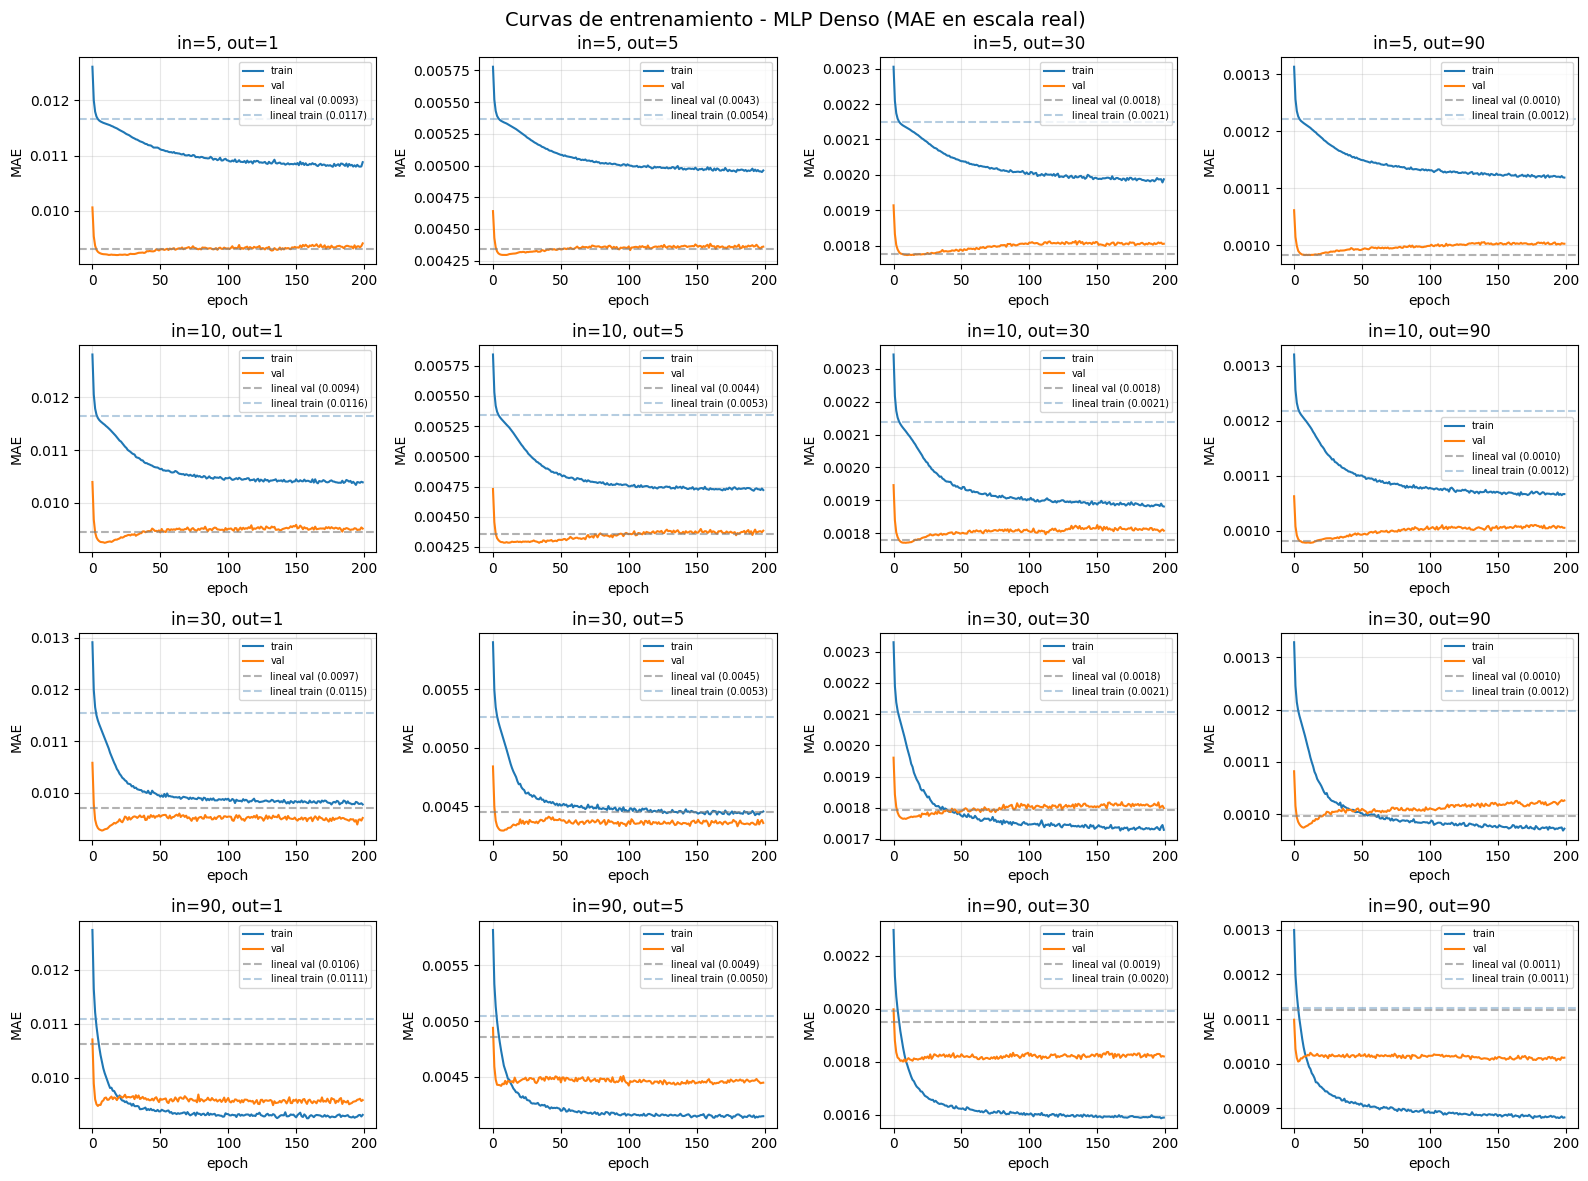

In [202]:
import matplotlib.pyplot as plt

# Cargar resultados de regresión lineal para usar como referencia
df_lineal = pd.read_csv('../results/regresion_lineal_resultados.csv')

fig, axes = plt.subplots(4, 4, figsize=(16, 12))

for idx, (in_w, out_w) in enumerate(historiales.keys()):
    ax = axes[idx // 4, idx % 4]
    h = historiales[(in_w, out_w)]
    
    ax.plot(h['loss'], label='train', color='#1f77b4')
    ax.plot(h['val_loss'], label='val', color='#ff7f0e')
    
    # Referencia para curva de val (naranja)
    mae_lineal_val = df_lineal[
        (df_lineal['input_window'] == in_w) & 
        (df_lineal['output_window'] == out_w)
    ]['mae_val'].values[0]
    ax.axhline(mae_lineal_val, color='gray', linestyle='--', alpha=0.6,
            label=f'lineal val ({mae_lineal_val:.4f})')

    # Referencia para curva de train (azul)
    mae_lineal_train = df_lineal[
        (df_lineal['input_window'] == in_w) & 
        (df_lineal['output_window'] == out_w)
    ]['mae_train'].values[0]
    ax.axhline(mae_lineal_train, color='steelblue', linestyle='--', alpha=0.4,
            label=f'lineal train ({mae_lineal_train:.4f})')
    
    ax.set_title(f"in={in_w}, out={out_w}")
    ax.set_xlabel('epoch')
    ax.set_ylabel('MAE')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Curvas de entrenamiento - MLP Denso (MAE en escala real)", fontsize=14)
plt.tight_layout()
plt.savefig('../results/mlp_curvas_entrenamiento.png', dpi=100, bbox_inches='tight')
plt.show()

## Conclusiones

El MLP denso entrenado con StandardScaler ajustado solo en train (tanto 
para entrada como para salida) supera a la regresión lineal en 14 de las 
16 combinaciones de ventanas. Las curvas de entrenamiento, calculadas en 
escala real mediante el callback `MAERealCallback` y comparadas con el 
MAE de la regresión lineal (línea gris discontinua), permiten una lectura 
inmediata del comportamiento de cada modelo.

### Resultados frente a los baselines

Comparativa del MAE en test entre los tres modelos para una selección 
representativa de combinaciones:

| in/out | Buy and Hold | Reg. Lineal | MLP | Mejora MLP vs Lineal |
|--------|-------------|-------------|-----|----------------------|
| 5/1    | 0.01779     | 0.01167     | 0.01154 | +1.1% |
| 5/30   | 0.01252     | 0.00217     | 0.00217 | empate |
| 5/90   | 0.01225     | 0.00122     | 0.00123 | -1% |
| 10/1   | 0.01779     | 0.01198     | 0.01156 | +3.5% |
| 30/1   | 0.01408     | 0.01244     | 0.01153 | **+7.3%** |
| 90/1   | 0.01411     | 0.01366     | 0.01177 | **+13.8%** |
| 90/5   | 0.02149     | 0.00596     | 0.00544 | +8.7% |
| 90/30  | 0.00486     | 0.00240     | 0.00212 | +11.7% |
| 90/90  | 0.00815     | 0.00136     | 0.00121 | +11.0% |

### Observaciones principales

- **El MLP supera la regresión lineal en la mayoría de combinaciones.** 
  En ventanas de entrada medias y largas (10, 30, 90), la red consigue 
  aprovechar la información temporal mejor que la regresión lineal, sobre 
  todo cuando esta última empezaba a sufrir por exceso de parámetros sin 
  regularización. La mejora más notable es en `in=90, out=1`: de 0.01366 
  a 0.01177, casi un 14% menos.

- **No supera la regresión lineal en `in=5, out=30` ni `in=5, out=90`.** 
  Con tan poca información de entrada (5 días × 23 activos = 115 valores), 
  la red no consigue aprender patrones útiles y la regresión lineal, más 
  robusta a la falta de datos, gana o empata. Es un resultado interesante: 
  las redes neuronales no son siempre la mejor opción, especialmente 
  cuando la señal disponible es limitada.

- **Mejora marginal en ventanas cortas y output=1.** Para combinaciones 
  como 5/1 o 5/5, la mejora es del 1-3%. Coherente con que el problema de 
  predecir un día individual está dominado por ruido aleatorio: hay un 
  techo fundamental que ningún modelo puede superar dada la naturaleza 
  inherente de los datos.

- **El MAE decrece fuertemente con la ventana de salida.** En todas las 
  combinaciones, el MAE pasa de ~0.012 (out=1) a ~0.0012 (out=90), un 
  orden de magnitud menos. Refleja la cancelación del ruido al promediar 
  muchos returns: predecir promedios largos es intrínsecamente más fácil 
  que predecir el siguiente día individual.

- **Overfitting controlado por EarlyStopping.** Las curvas en `in=30/90` 
  muestran el patrón clásico de overfitting (train sigue bajando, val se 
  aplana o sube ligeramente). El callback con `restore_best_weights=True` 
  recupera los pesos del momento de mínimo val_loss, evitando que el 
  modelo final esté contaminado por la memorización del train. Los MAE 
  test reportados son, por tanto, consistentes con val y no con el train 
  final.

- **Convergencia ideal en algunas combinaciones.** Casos como 
  `in=10, out=30` muestran train y val descendiendo juntos hasta cruzar 
  la línea gris de la regresión lineal. Es el escenario óptimo: el modelo 
  aprende generalización real, no memorización.

- **Más parámetros NO siempre mejoran resultados.** Modelos con 274.839 
  parámetros (input_window=90) y modelos con 24.599 parámetros 
  (input_window=5) dan MAE muy similares en `output=1` (0.01177 vs 0.01154 
  respectivamente). La capacidad del modelo no es el cuello de botella: 
  el problema es la señal disponible en los datos. Esto motiva el uso de 
  arquitecturas que comparten pesos (recurrente, convolucional) en los 
  siguientes notebooks.

- **El número de epochs efectivamente entrenadas oscila entre 9 y 16** 
  (sobre un máximo de 50), lo que indica que EarlyStopping está deteniendo 
  el entrenamiento de forma inteligente, sin agotar el presupuesto en 
  ningún caso.

### Conclusión general

El MLP denso queda como un primer modelo neuronal sólido: bate al baseline 
de regresión lineal en la mayoría de combinaciones y demuestra que la 
no-linealidad aporta valor real al problema. Las dos combinaciones donde 
no supera al baseline (`in=5, out=30/90`) constituyen un resultado honesto 
sobre los límites de las redes con poca información de entrada.

Estos resultados establecen un nuevo listón para las arquitecturas 
recurrente, convolucional y mixta. La pregunta abierta para los siguientes 
modelos es si arquitecturas que comparten pesos a lo largo del tiempo 
pueden mejorar todavía más con muchos menos parámetros que estos 24K-275K.